<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_68_gradient_boost_step_by_step/Lecture_68_gradient_boost_step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import the necessary libraries for numerical operations, plotting, and data manipulation.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# Set a random seed for reproducibility.
np.random.seed(42)
# Generate synthetic data for X (100 points between -0.5 and 0.5).
X = np.random.rand(100, 1) - 0.5
# Generate synthetic data for y based on a quadratic relationship with added random noise.
y = 3*X[:, 0]**2 + 0.05*np.random.randn(100)

In [4]:
# Initialize an empty pandas DataFrame.
df = pd.DataFrame()

In [5]:
# Add the generated X and y data to the DataFrame as new columns.
df['X'] = X.reshape(100)
df['y'] = y

In [6]:
# Display the first few rows of the DataFrame.
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0, 0.5, 'y')

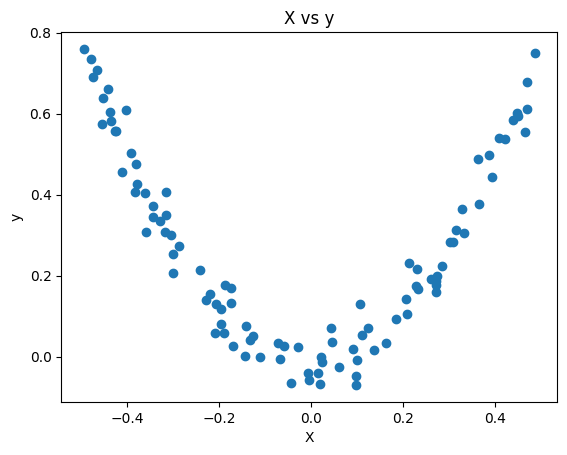

In [7]:
# Create a scatter plot of the 'X' and 'y' data.
plt.scatter(df['X'], df['y'])
# Set the title of the plot.
plt.title('X vs y')
# Set the label for the x-axis.
plt.xlabel('X')
# Set the label for the y-axis.
plt.ylabel('y')

In [8]:
# Calculate the mean of the 'y' column and add it as 'pred1' (initial prediction).
df['pred1'] = df['y'].mean()

In [9]:
# Display the DataFrame with the 'pred1' column.
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [10]:
# Calculate the residuals (errors) of the initial prediction and add as 'res1'.
df['res1'] = df['y'] - df['pred1']

In [11]:
# Display the DataFrame with the 'res1' column.
df

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


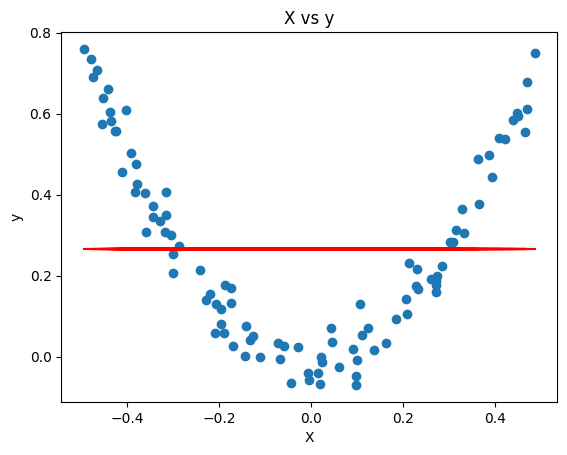

In [12]:
# Replot the scatter plot of 'X' vs 'y'.
plt.scatter(df['X'], df['y'])
# Set title and axis labels.
plt.title('X vs y')
plt.xlabel('X')
plt.ylabel('y')
# Plot the initial prediction ('pred1') as a red line.
plt.plot(df['X'], df['pred1'], color='red')

In [13]:
# Import the DecisionTreeRegressor for building decision trees.
from sklearn.tree import DecisionTreeRegressor

In [14]:
# Initialize a DecisionTreeRegressor model with max_leaf_nodes set to 8.
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [15]:
# Train the first decision tree on 'X' to predict the residuals 'res1'.
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

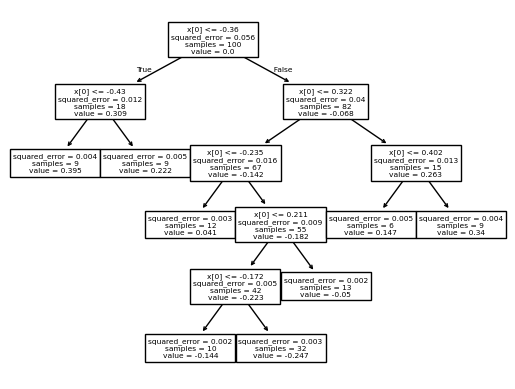

In [16]:
# Import plot_tree to visualize the decision tree.
from sklearn.tree import plot_tree
# Plot the first decision tree.
plot_tree(tree1)
# Display the plot.
plt.show()

In [17]:
# Create a sequence of 500 evenly spaced values for testing predictions.
X_test = np.linspace(-0.5, 0.5, 500)

In [18]:
# Calculate the combined prediction from the initial mean and the first tree on X_test.
y_pred = 0.265458 + tree1.predict(X_test.reshape(500,1))

Text(0, 0.5, 'y')

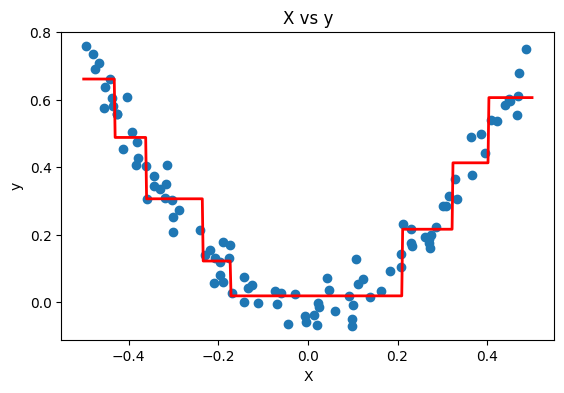

In [19]:
# Create a figure with a single subplot for plotting.
plt.figure(figsize=(14, 4))
plt.subplot(121)
# Plot the combined prediction as a red line.
plt.plot(X_test, y_pred, linewidth=2, color='red')
# Plot the original data as scatter points.
plt.scatter(df['X'], df['y'])
# Set title and axis labels.
plt.title('X vs y')
plt.xlabel('X')
plt.ylabel('y')

In [20]:
# Calculate the combined prediction from the initial mean and the first tree on the original X data.
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [21]:
# Display the DataFrame with the 'pred2' column.
df

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018319
4,-0.343981,0.343986,0.265458,0.078528,0.305964
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319
96,0.022733,-0.002305,0.265458,-0.267763,0.018319
97,-0.072459,0.032809,0.265458,-0.232650,0.018319
98,-0.474581,0.689516,0.265458,0.424057,0.660912


In [22]:
# Calculate the residuals of the combined prediction ('pred2') and add as 'res2'.
df['res2'] = df['y'] - df['pred2']

In [23]:
# Display the DataFrame with the 'res2' column.
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [24]:
# Initialize a second DecisionTreeRegressor model with max_leaf_nodes set to 8.
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

In [25]:
# Train the second decision tree on 'X' to predict the residuals 'res2'.
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [27]:
# Calculate the cumulative prediction from the initial mean, tree1, and tree2 on X_test.
y_pred = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])

Text(0, 0.5, 'y')

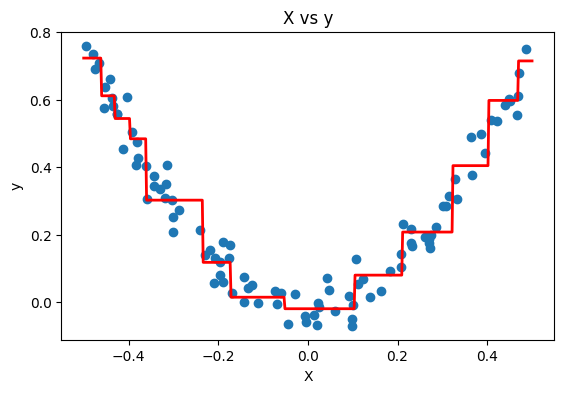

In [28]:
# Create a figure with a single subplot for plotting.
plt.figure(figsize=(14, 4))
plt.subplot(121)
# Plot the cumulative prediction as a red line.
plt.plot(X_test, y_pred, linewidth=2, color='red')
# Plot the original data as scatter points.
plt.scatter(df['X'], df['y'])
# Set title and axis labels.
plt.title('X vs y')
plt.xlabel('X')
plt.ylabel('y')

In [31]:
# Define a recursive function to demonstrate the gradient boosting process.
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  # Base case: stop when the desired number of boosting stages is reached.
  if number == 0:
    return
  else:
    # Perform gradient boosting step.

    # Calculate the target for the current tree (residuals).
    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      # Store the original target variable for plotting.
      foo = y

    # Initialize and train a DecisionTreeRegressor on the current residuals.
    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    # Add the trained tree to the list of regressors.
    regs.append(tree_reg)

    # Generate points for plotting the prediction curve.
    x1 = np.linspace(-0.5, 0.5, 500)
    # Calculate the cumulative prediction from all trained trees.
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    # Print the current boosting stage number.
    print(number)
    # Create a new figure for plotting the current stage's prediction.
    plt.figure()
    # Plot the cumulative prediction curve.
    plt.plot(x1, y_pred, linewidth=2)
    # Plot the original data points.
    plt.plot(X[:, 0], foo,"r.")
    # Display the plot.
    plt.show()

    # Recursively call gradient_boost for the next stage.
    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

5


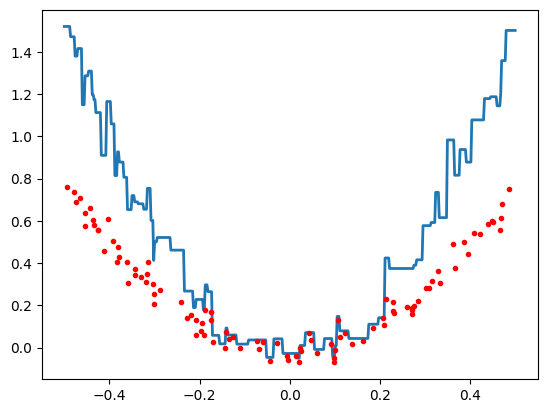

4


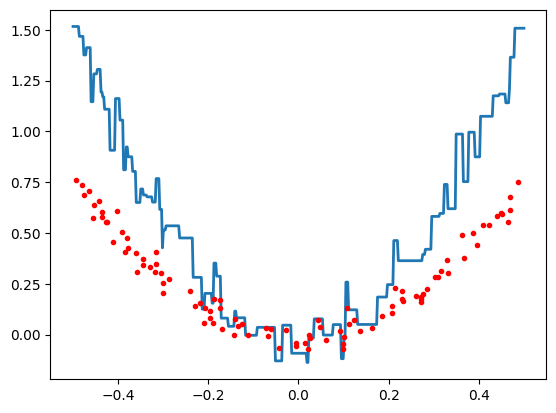

3


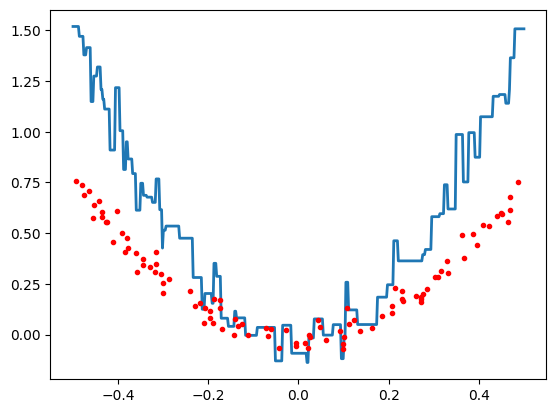

2


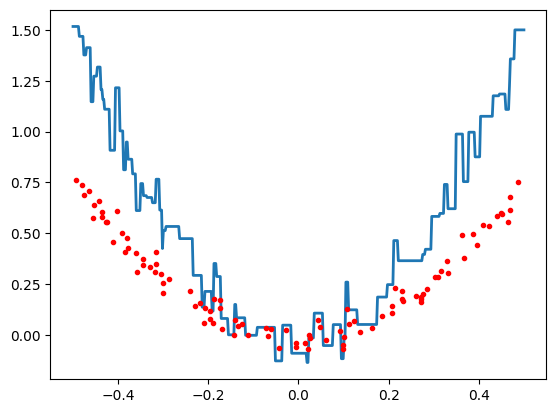

1


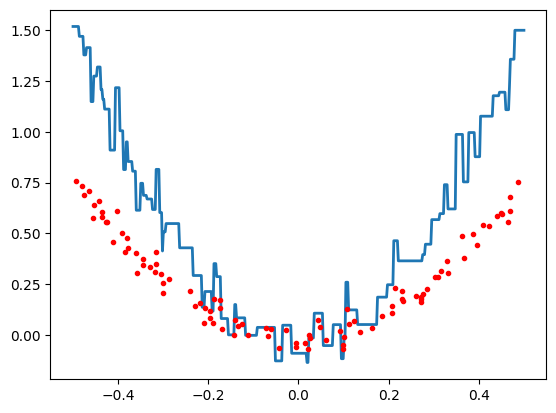

In [33]:
# Set the random seed for reproducibility.
np.random.seed(42)
# Regenerate the synthetic data for X and y.
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
# Call the gradient_boost function to perform 5 boosting stages with a learning rate of 1.
gradient_boost(X,y,5,lr=1)